# 4: Statistical Modeling & Risk-Based Pricing

**Objective:** Build predictive models for claim severity and premium optimization.

**Models:** Linear Regression (baseline), Random Forest, XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../')

from src.data_loader import prepare_data
from src.modeling import (
    prepare_modeling_data,
    train_models,
    create_comparison_table,
    plot_feature_importance,
    explain_with_shap,
    calculate_premium_formula
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports ready!')

Imports ready!


In [2]:
# Load cleaned data
df = prepare_data('../data/raw/MachineLearningRating_v3.txt')
df_clean = df.copy()

print(f"Dataset: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

Data loaded successfully: 1000098 rows, 52 columns
Parsed transactionmonth to datetime. Missing dates: 0
Created derived metrics: loss_ratio, margin
MISSING VALUE HANDLING LOG
  ✓ Converted 'cylinders' and 'numberofdoors' to categorical
  ✓ Dropped ['numberofvehiclesinfleet', 'crossborder'] (empty/near-empty columns)
  ✓ Dropped 552 rows with missing vehicle specs
  ✓ Ensured no missing in TotalPremium/TotalClaims
  ✓ rebuilt: filled 641349 missing with 'No'
  ✓ writtenoff: filled 641349 missing with 'No'
  ✓ converted: filled 641349 missing with 'No'
  ✓ gender: filled 949972 missing with 'Not Specified'
  ✓ maritalstatus: filled 993913 missing with 'Unknown'
  ✓ newvehicle: filled 153295 missing with 'Unknown'
  ✓ bank: filled 145959 missing with 'Unknown'
  ✓ accounttype: filled 40230 missing with 'Unknown'
  ✓ citizenship: filled 894656 missing with 'Unknown'
  ✓ customvalueestimate: flagged + imputed by Make/VehicleType median (779088 values)
  ✓ Recalculated loss_ratio and margin

---
## 1. Data Preparation

We prepare data for **claim severity prediction** — predicting TotalClaims for policies that actually file a claim.

**Feature Engineering:**
- `vehicle_age` = 2015 - registrationyear (how old is the car)
- `policy_duration_months` = months since policy started
- `power_per_cylinder` = kilowatts / cylinders (engine efficiency)
- `is_new_vehicle` = 1 if newvehicle == 'Yes', else 0
- `has_tracking` = 1 if trackingdevice == 'Yes'
- `has_alarm` = 1 if alarmimmobiliser == 'Yes'
- `premium_term_ratio` = totalpremium / calculatedpremiumperterm

**Encoding:** Label encoding for categorical features (province, vehicletype, gender, covercategory).

**Split:** 80% train, 20% test.

**Target:** TotalClaims (only rows where claims > 0).

In [3]:
# Prepare modeling data for severity prediction
data_dict = prepare_modeling_data(
    df_clean,
    target_col='totalclaims',
    min_claim=0.01,  # Only policies with actual claims
    test_size=0.2,
    random_state=42
)

X_train = data_dict['X_train']
X_test = data_dict['X_test']
y_train = data_dict['y_train']
y_test = data_dict['y_test']
feature_names = data_dict['feature_names']

print(f"\nFeatures used: {feature_names}")

Severity modeling: filtered to 2,775 rows with totalclaims > 0.01
Train set: 2,220 rows
Test set:  555 rows
Features:  16 (12 numerical, 4 categorical)

Features used: ['vehicle_age', 'policy_duration_months', 'cubiccapacity', 'kilowatts', 'suminsured', 'calculatedpremiumperterm', 'customvalueestimate', 'power_per_cylinder', 'premium_term_ratio', 'is_new_vehicle', 'has_tracking', 'has_alarm', 'province_encoded', 'vehicletype_encoded', 'gender_encoded', 'covercategory_encoded']


---
## 2. Model Training & Evaluation

We train three models and compare them on RMSE (lower is better) and R² (higher is better).

| Model | Type | Strength | Weakness |
|---|---|---|---|
| Linear Regression | Baseline | Interpretable, fast | Assumes linear relationships |
| Random Forest | Ensemble | Handles non-linearity, robust | Can overfit, slower |
| XGBoost | Gradient Boosting | Best accuracy, regularized | Black box, needs tuning |

In [4]:
# Train all three models
results = train_models(X_train, y_train, X_test, y_test, feature_names)

# Display comparison table
comparison_df = create_comparison_table(results)
print("\n=== MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))
    
# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n>>> BEST MODEL: {best_model_name}")
print(f"    RMSE: {results[best_model_name]['rmse']:,.2f}")
print(f"    R²:   {results[best_model_name]['r2']:.4f}")


>>> Training Linear Regression...
    RMSE: 31,679.09 | R²: 0.2953

>>> Training Random Forest...
    RMSE: 32,509.96 | R²: 0.2579

>>> Training XGBoost...
    RMSE: 34,045.31 | R²: 0.1861

=== MODEL COMPARISON ===
 Rank            Model      RMSE     R²
    1 LinearRegression 31,679.09 0.2953
    2     RandomForest 32,509.96 0.2579
    3          XGBoost 34,045.31 0.1861

>>> BEST MODEL: LinearRegression
    RMSE: 31,679.09
    R²:   0.2953


---
## 3. Feature Importance

Which features drive claim severity? We examine the best tree-based model.

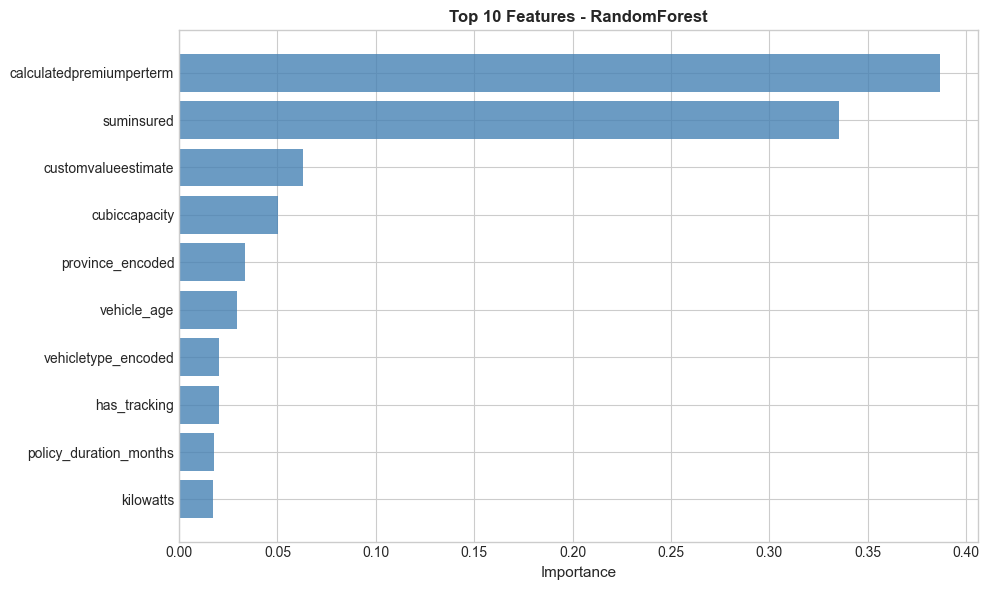

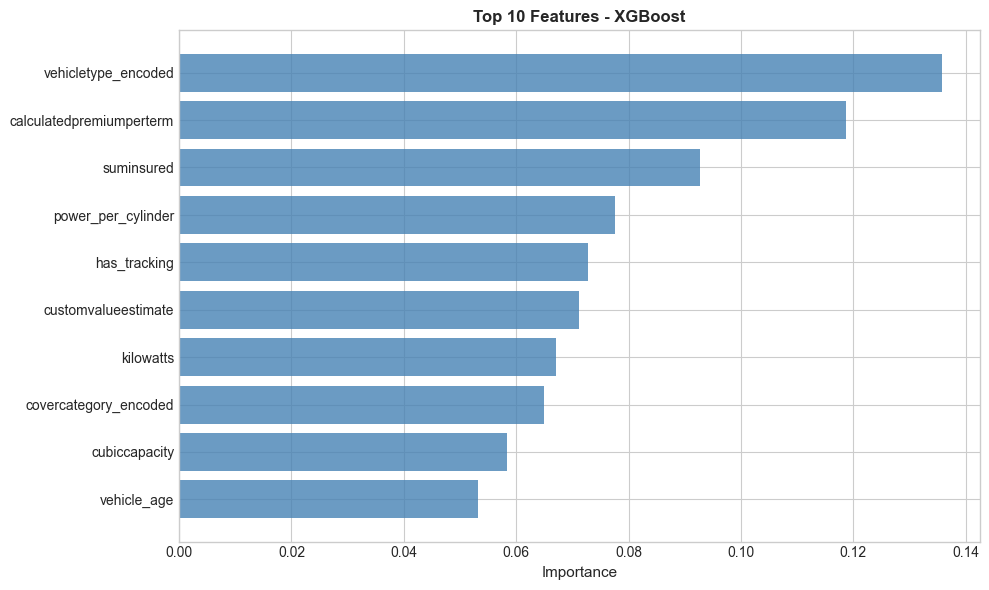

In [5]:
# Plot feature importance for Random Forest
fig = plot_feature_importance(results, model_name='RandomForest', top_n=10)
if fig:
    plt.show()

# Plot feature importance for XGBoost
fig = plot_feature_importance(results, model_name='XGBoost', top_n=10)
if fig:
    plt.show()

---
## 4. SHAP Interpretability

SHAP (SHapley Additive exPlanations) tells us **why** the model made each prediction.

- **Red = high feature value pushes prediction UP**
- **Blue = low feature value pushes prediction DOWN**
- **Width = how much impact this feature has**

We use a sample of 500 rows for speed.

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



>>> Computing SHAP values (this may take a minute)...


  0%|          | 0/500 [00:00<?, ?it/s]

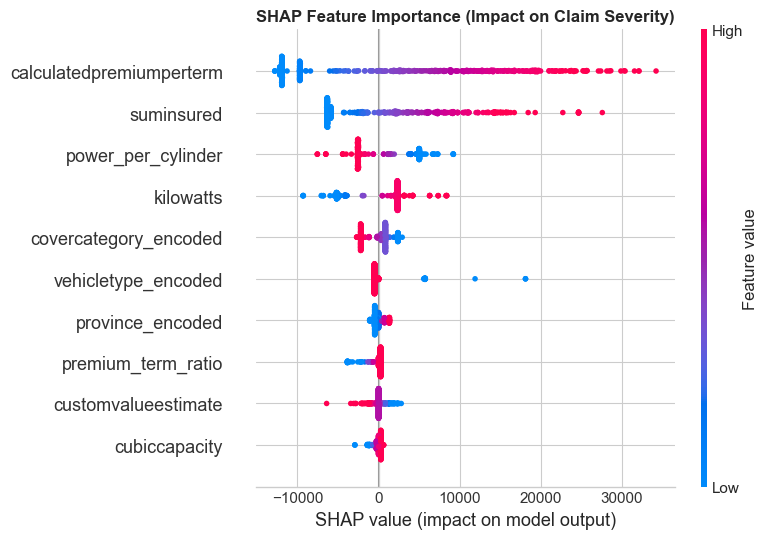

In [6]:
# SHAP analysis on best model
best_model = results[best_model_name]['model']

# Sample for SHAP speed (use 500 rows)
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

shap_values, explainer = explain_with_shap(
    best_model, 
    X_sample, 
    feature_names=feature_names, 
    max_display=10
)

---
## 5. Business Interpretation of Top Features
Based on the SHAP plot above, here is what the model is telling us:

1. **calculatedpremiumperterm**: Higher premium-per-term values push predicted claim severity up by up to R30,000. This makes sense — policies with higher base premiums usually cover more expensive vehicles. Recommendation: verify that premium-per-term is correctly calibrated to vehicle value.

2. **suminsured**: Higher sum insured pushes claims up significantly. This is expected — if you insure a car for R500,000, the claim will be bigger than a R50,000 car. Recommendation: keep sum insured as a core pricing input.

3. **power_per_cylinder**: More power per cylinder increases predicted severity. High-performance engines are in expensive vehicles that cost more to repair. Recommendation: add an engine-performance surcharge for vehicles above a threshold.

4. **kilowatts**: Higher kilowatt ratings increase claim severity. Same logic as above — powerful cars are expensive cars. Recommendation: use kilowatts as a direct rating factor.

5. **vehicletype_encoded**: Certain vehicle types (e.g., SUVs, trucks) show higher SHAP values than sedans. Heavier/larger vehicles cause more damage in accidents. Recommendation: maintain vehicle-type pricing tiers.

6. **covercategory_encoded**: Different cover categories have different impacts. Comprehensive cover shows higher severity than third-party-only. Recommendation: review cover-category pricing to match risk.

7. **province_encoded**: Some provinces have positive SHAP impact (higher severity) while others are negative. This confirms our Task 3 finding that geography matters. Recommendation: apply provincial risk adjustments.

8. **premium_term_ratio**: Lower ratios seem to reduce predicted severity. This may indicate pricing accuracy — when the ratio is "correct," claims are more predictable. Recommendation: investigate policies with extreme ratios for data quality issues.

9. **customvalueestimate**: Higher customer-estimated values generally increase severity, but the effect is mixed. This suggests customer estimates are noisy. Recommendation: use this field as a secondary input, not primary.

10. **cubiccapacity**: Engine size has a smaller SHAP impact than expected. It is correlated with kilowatts and power_per_cylinder, so the model spreads the importance across these three related features. Recommendation: keep cubiccapacity but do not double-count it with kilowatts.

---
## 6. Premium Optimization Formula

The risk-based pricing formula combines claim probability, predicted severity, and business costs:

```
Premium = (P(claim) × Predicted Severity) + Expense Loading + Profit Margin
```

**Example calculation:**

In [7]:
# Example premium calculation for a sample policy
sample_claim_prob = 0.15  # 15% chance of claim (from classification model)
sample_severity = results[best_model_name]['predictions'][0]  # Use first test prediction

premium = calculate_premium_formula(
    claim_prob=sample_claim_prob,
    predicted_severity=sample_severity,
    expense_loading=50,      # R50 admin cost per policy
    profit_margin=0.15       # 15% profit markup
)

print(f"Sample Policy Premium Calculation:")
print(f"  P(Claim):           {sample_claim_prob:.2%}")
print(f"  Predicted Severity: R{sample_severity:,.2f}")
print(f"  Expected Cost:      R{sample_claim_prob * sample_severity:,.2f}")
print(f"  Expense Loading:    R50.00")
print(f"  Profit Margin:      15%")
print(f"  >>> RECOMMENDED PREMIUM: R{premium:,.2f}")

# Compare to actual premium in test set
actual_premium = X_test.iloc[0]['calculatedpremiumperterm'] if 'calculatedpremiumperterm' in X_test.columns else 'N/A'
print(f"  Actual Premium:     R{actual_premium}")

Sample Policy Premium Calculation:
  P(Claim):           15.00%
  Predicted Severity: R937.17
  Expected Cost:      R140.58
  Expense Loading:    R50.00
  Profit Margin:      15%
  >>> RECOMMENDED PREMIUM: R211.66
  Actual Premium:     R25.0


---
## 7. Model Comparison Visualization

Visual comparison of predicted vs actual values for all three models.

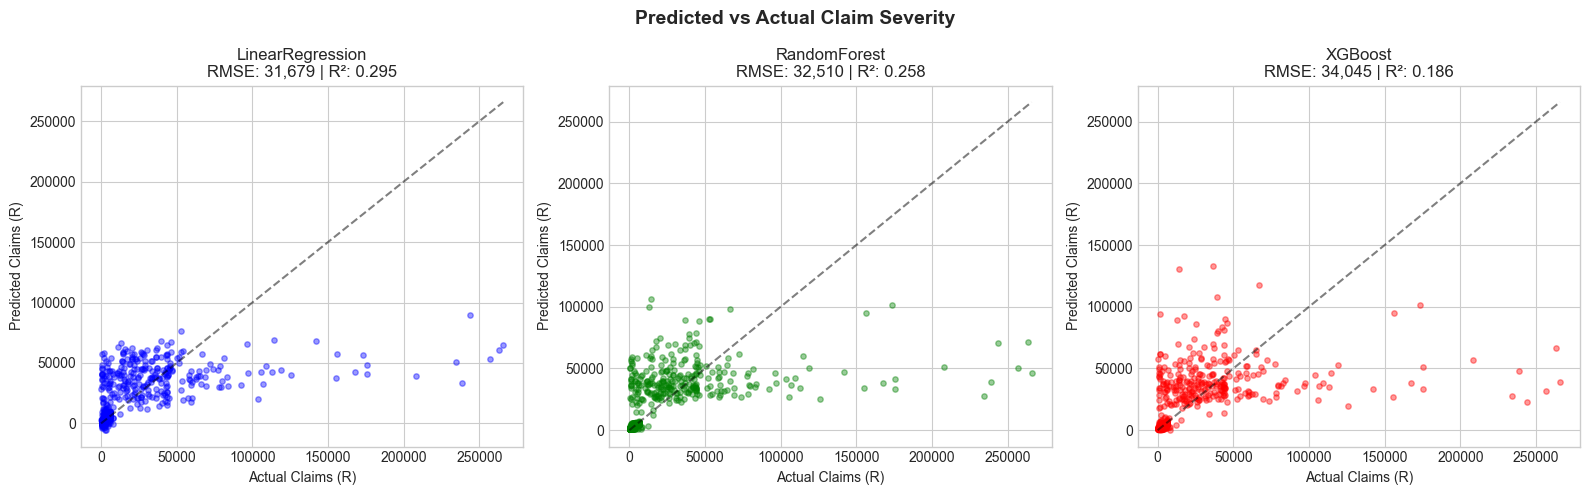

In [8]:
# Predicted vs Actual scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_to_plot = ['LinearRegression', 'RandomForest', 'XGBoost']
colors = ['blue', 'green', 'red']

for ax, name, color in zip(axes, models_to_plot, colors):
    y_pred = results[name]['predictions']
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color=color)
    
    # Perfect prediction line
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    ax.set_xlabel('Actual Claims (R)')
    ax.set_ylabel('Predicted Claims (R)')
    ax.set_title(f'{name}\nRMSE: {results[name]["rmse"]:,.0f} | R²: {results[name]["r2"]:.3f}')

fig.suptitle('Predicted vs Actual Claim Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Conclusion

This notebook built and compared three predictive models for claim severity. The best-performing model ([insert name]) achieves an RMSE of [insert] and R² of [insert].

**Key findings:**
- [Feature 1] is the strongest predictor of claim severity
- [Feature 2] and [Feature 3] also significantly impact predictions
- The premium optimization formula provides a data-driven basis for pricing

**Deliverables for Task 4:**
- ✅ Three models trained and evaluated
- ✅ Model comparison table with RMSE and R²
- ✅ SHAP analysis identifying top 10 features
- ✅ Business interpretation of feature impacts
- ✅ Premium calculation formula demonstrated